##### imports

# TO-DO:
- "Normal" run
    - confusion matrix
    - classification report
- Augmentated run
- (eventually) custom CNN

In [ ]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.applications import MobileNetV2
from keras import layers
from tensorflow import data as tf_data
import os
import random
import zipfile
import shutil
import pandas as pd
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay,classification_report)

import reload_data2 as reloadata

#### Data loading

In [ ]:
try:
    shutil.rmtree("/content/Handwriting_Images")
except:
    pass

!unzip /content/Handwriting_Images_90sorted.zip

Archive:  /content/Handwriting_Images_90sorted.zip
   creating: Handwriting_Images/
  inflating: __MACOSX/._Handwriting_Images  
   creating: Handwriting_Images/w0129/
   creating: Handwriting_Images/w0142/
   creating: Handwriting_Images/w0145/
   creating: Handwriting_Images/w0128/
   creating: Handwriting_Images/w0126/
   creating: Handwriting_Images/w0121/
   creating: Handwriting_Images/w0144/
   creating: Handwriting_Images/w0143/
   creating: Handwriting_Images/w0031/
   creating: Handwriting_Images/w0009/
   creating: Handwriting_Images/w0036/
   creating: Handwriting_Images/w0038/
  inflating: Handwriting_Images/.DS_Store  
  inflating: __MACOSX/Handwriting_Images/._.DS_Store  
   creating: Handwriting_Images/w0062/
   creating: Handwriting_Images/w0091/
   creating: Handwriting_Images/w0006/
   creating: Handwriting_Images/w0001/
   creating: Handwriting_Images/w0030/
   creating: Handwriting_Images/w0064/
   creating: Handwriting_Images/w0063/
   creating: Handwriting_Images

In [ ]:
shutil.rmtree("/content/__MACOSX")

In [ ]:
help(reloadata)

Help on module reload_data2:

NAME
    reload_data2

FUNCTIONS
    apply_augmentations()
        Apply `data_augmentation` to the training images.

    data_augmentation(images)
        Function for testing augmentations with test_augmentations(), not meant for use

        For applying augmentations, use: apply_augmentations()

    del_old_writer_directories(source_dir)
        Deletes original writer-organized directories (for use after creating train/val/test directories with stratify_split())

    full_unzip_and_stratify(path_of_zipfile, source_dir, IMAGE_SIZE=(384, 384), BATCH_SIZE=18)
        Starts with zipped file, divides unzipped images by author, splits sorted images into train/val/test images,
        creates & returns train/val/test datatsets

    organize_unzipped_files(source_dir)
        Organizes raw unzipped files into writer folders

    stratify_split(source_dir, split=[15, 6, 6])
        Re-organizes images in writer folders into train/val/test folders with writer 

In [ ]:
data_folder_path = "/content/Handwriting_Images"

In [ ]:
def alt_make_transfer_model(input_shape, num_classes, modname):
    backbone = base_model
    backbone.trainable = False

    inputs = layers.Input(input_shape)
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = backbone(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes, activation=None)(x)

    return keras.Model(inputs, outputs, name=modname)

# Modelling

In [ ]:
IMAGE_SIZE = (384, 384)#(256,256)
BATCH_SIZE = 64
INPUT_SHAPE = IMAGE_SIZE + (3,)
NUM_CLASSES = 90

### train/tes/val

In [ ]:
#normal 60/20/20 split
reloadata.stratify_split_alt(data_folder_path,split=(15, 6, 6))

train_ds,val_ds,test_ds=reloadata.train_val_test_split(data_folder_path,
                                                       IMAGE_SIZE,
                                                       BATCH_SIZE)
reloadata.del_old_writer_directories(data_folder_path)

Found 1350 files belonging to 90 classes.
Found 540 files belonging to 90 classes.
Found 540 files belonging to 90 classes.


#### Visualizing images

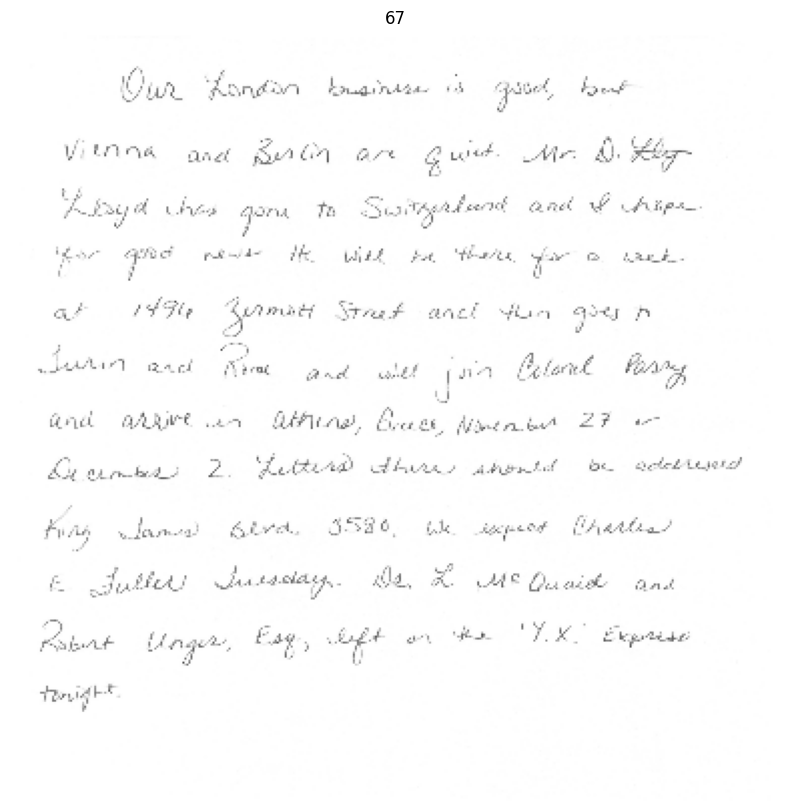

In [ ]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(10, 10))
for i in range(1):
    #plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(labels[i].numpy())
    plt.axis("off")
plt.show()

    (256,256) --> pixel limitations affecting readability
    (384,384) --> readable

## 100 epochs

In [ ]:
base_model = MobileNetV2(include_top = False,
                        classifier_activation="softmax",
                        weights = "imagenet",
                        input_shape=(IMAGE_SIZE + (3,))
                        )

def alt_make_transfer_model(input_shape, num_classes, modname):
    backbone = base_model
    backbone.trainable = False

    inputs = layers.Input(input_shape)
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = backbone(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes, activation=None)(x)

    return keras.Model(inputs, outputs, name=modname)

model = alt_make_transfer_model(input_shape=INPUT_SHAPE, num_classes=90,
                                modname="normal75")

backbone = model.get_layer("mobilenetv2_1.00_224")
backbone.trainable = True
for layer in backbone.layers[:-5]:
    layer.trainable = False

/tmp/ipython-input-3964100014.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(include_top = False,


In [ ]:
model.summary()

Model: "normal75"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 12, 12, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 90)             │       115,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,373,274 (9.05 MB)

 Trainable params: 835,290 (3.19 MB)

 Non-trainable params: 1,537,984 (5.87 MB)

In [ ]:
%%time

epochs = 100

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc"),
             keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")],
    )

history = model.fit(
    train_ds,
    epochs= epochs,
    validation_data= val_ds)

model.save("/content/MobileNet_normal100.keras")

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - acc: 0.0138 - loss: 4.7385 - top3_acc: 0.0315 - val_acc: 0.0185 - val_loss: 4.8976 - val_top3_acc: 0.0500
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 274ms/step - acc: 0.0221 - loss: 4.6134 - top3_acc: 0.0511 - val_acc: 0.0204 - val_loss: 4.8778 - val_top3_acc: 0.0500
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 281ms/step - acc: 0.0212 - loss: 4.5367 - top3_acc: 0.0441 - val_acc: 0.0204 - val_loss: 4.8581 - val_top3_acc: 0.0500
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 274ms/step - acc: 0.0253 - loss: 4.4626 - top3_acc: 0.0649 - val_acc: 0.0204 - val_loss: 4.8304 - val_top3_acc: 0.0537
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 292ms/step - acc: 0.0388 - loss: 4.3999 - top3_acc: 0.0937 - val_acc: 0.0222 - val_loss: 4.7985 - val_top3_acc: 0.0556
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 273ms/step - acc: 0.0499 - loss: 4.3312 - top3_acc: 0.1089 - val_acc: 0.0259 - val_loss: 4.7642 - val_top3_acc: 0.0630
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━

In [ ]:
lossacc = pd.DataFrame(history.history)
lossacc.to_csv("normal100_lossacc.csv")

#### Visualization/Evalution

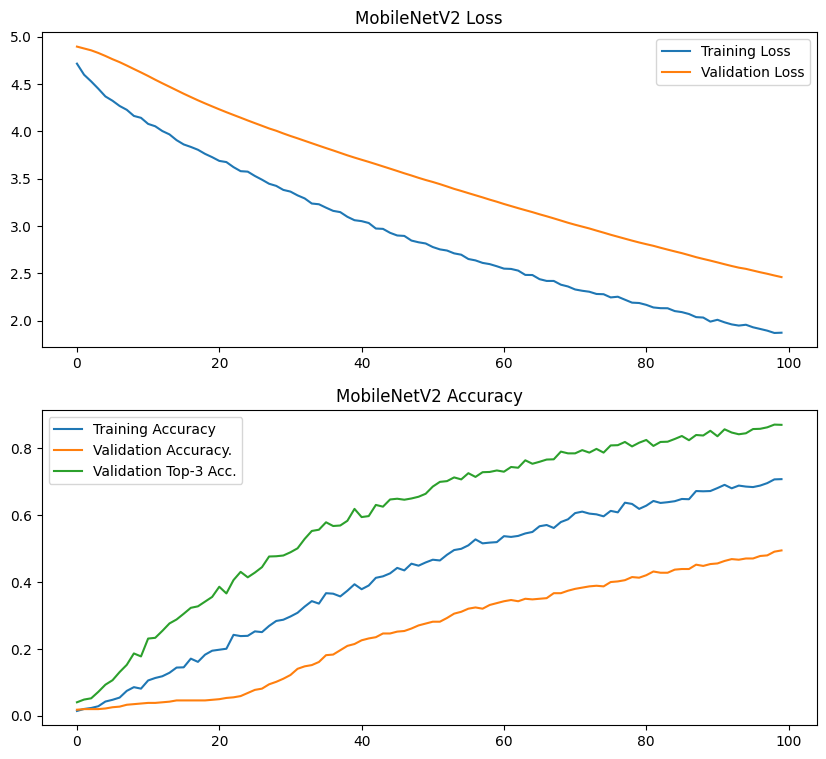

In [ ]:
#plot loss and accuracy curves
plt.figure(figsize=(10,9))
#plt.suptitle("",size=18)
plt.subplot(2,1,1)
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history.history["acc"])),history.history["acc"],label="Training Accuracy")
plt.plot(range(len(history.history["val_acc"])),history.history["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(history.history["top3_acc"])),history.history["top3_acc"],label="Validation Top-3 Acc.")
plt.title("MobileNetV2 Accuracy")
plt.legend()

plt.show()

In [ ]:
#test_loss, test_acc = model.evaluate(test_ds)
results = model.evaluate(test_ds, return_dict=True)

print(results)

#print(f"Test accuracy: {test_acc:.3f}")
#print(f"Test loss: {test_loss:.3f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - acc: 0.4358 - loss: 2.5347 - top3_acc: 0.6802
{'acc': 0.4555555582046509, 'loss': 2.552764654159546, 'top3_acc': 0.6814814805984497}


In [ ]:
#Get predictions
y_pred_logits = model.predict(test_ds)
y_pred = np.argmax(y_pred_logits, axis=1)

y_true = np.concatenate([
    y.numpy() for _, y in test_ds
])

9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 923ms/step


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=reloadata.w_ids,
    digits=4
))

              precision    recall  f1-score   support

       w0001     0.0000    0.0000    0.0000         6
       w0002     0.0000    0.0000    0.0000         6
       w0003     0.0000    0.0000    0.0000         6
       w0004     0.0000    0.0000    0.0000         6
       w0005     0.0476    0.1667    0.0741         6
       w0006     0.0000    0.0000    0.0000         6
       w0009     0.0000    0.0000    0.0000         6
       w0010     0.0000    0.0000    0.0000         6
       w0011     0.0000    0.0000    0.0000         6
       w0012     0.0000    0.0000    0.0000         6
       w0013     0.0000    0.0000    0.0000         6
       w0015     0.0000    0.0000    0.0000         6
       w0016     0.0000    0.0000    0.0000         6
       w0017     0.0000    0.0000    0.0000         6
       w0018     0.0000    0.0000    0.0000         6
       w0020     0.0000    0.0000    0.0000         6
       w0022     0.0000    0.0000    0.0000         6
       w0023     0.0000    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


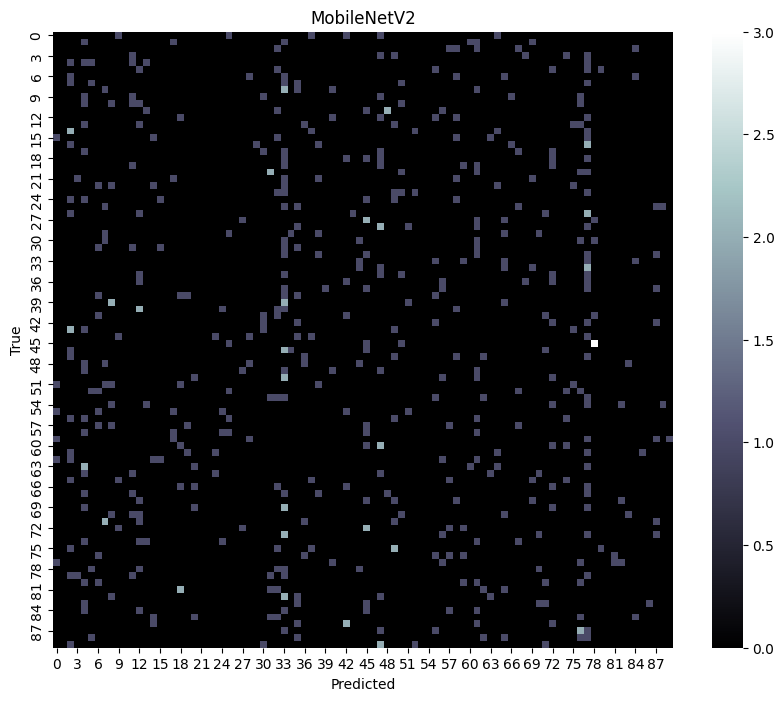

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.title("MobileNetV2")
sns.heatmap(cm, annot=False, cmap="bone")
plt.xlabel("Predicted")
plt.ylabel("True")
#plt.title("Confusion Matrix")
plt.show()

# Augmentations

    Zoom + crop on train set
    anticipated to capture whitespace

In [ ]:
IMAGE_SIZE=(320,320)
BATCH_SIZE = 64
INPUT_SHAPE = IMAGE_SIZE + (3,)
NUM_CLASSES = 90

In [ ]:
def get_paths_and_labels(root_dir):
    class_names = sorted(os.listdir(root_dir)) #w_ids list
    class_to_idx = {name: i for i, name in enumerate(class_names)} #dict of writer to index

    paths = [] #list of every image's path
    labels = [] #list of every image's writer class

    for class_name in class_names: #for writer in w_ids
        class_dir = os.path.join(root_dir, class_name) #writer subfolder
        for fname in os.listdir(class_dir): #loops over every image in writer subfolder
            paths.append(os.path.join(class_dir, fname))
            labels.append(class_to_idx[class_name])

    return paths, labels, class_names

train_paths, train_labels, class_names = get_paths_and_labels(f"{data_folder_path}/train")
val_paths, val_labels, _ = get_paths_and_labels(f"{data_folder_path}/val")
test_paths, test_labels, _ = get_paths_and_labels(f"{data_folder_path}/test")

In [ ]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    return img, label

def random_crop_zoom(img, label):
    shape = tf.shape(img)
    h, w = shape[0], shape[1]

    crop_frac = tf.random.uniform([], 0.6, 0.9)
    crop_h = tf.cast(crop_frac * tf.cast(h, tf.float32), tf.int32)
    crop_w = tf.cast(crop_frac * tf.cast(w, tf.float32), tf.int32)

    img = tf.image.random_crop(img, [crop_h, crop_w, 3])
    return img, label

def resize_for_model(img, label):
    img = tf.image.resize(img, IMAGE_SIZE, method="area")
    return img, label

In [ ]:
pd.DataFrame(train_labels).value_counts().sum()/90

np.float64(15.0)

In [ ]:
train_pathslabels = list(zip(train_labels,train_paths))
val_pathslabels = list(zip(val_labels,val_paths))
test_pathslabels = list(zip(test_labels,test_paths))

In [ ]:
train_dict=dict()
val_dict=dict()
test_dict=dict()
for ind,writer in enumerate(reloadata.w_ids):
    train_dict[ind]=os.listdir(f"{data_folder_path}/train/{writer}")
    val_dict[ind]=os.listdir(f"{data_folder_path}/val/{writer}")
    test_dict[ind]=os.listdir(f"{data_folder_path}/test/{writer}")

In [ ]:
train_dict

{0: ['w0001_s02_pPHR_r03.png',
  'w0001_s02_pWOZ_r02.png',
  'w0001_s01_pLND_r01.png',
  'w0001_s03_pPHR_r02.png',
  'w0001_s03_pPHR_r03.png',
  'w0001_s02_pLND_r02.png',
  'w0001_s01_pPHR_r02.png',
  'w0001_s03_pPHR_r01.png',
  'w0001_s01_pPHR_r01.png',
  'w0001_s02_pPHR_r02.png',
  'w0001_s03_pLND_r01.png',
  'w0001_s01_pWOZ_r01.png',
  'w0001_s02_pLND_r03.png',
  'w0001_s03_pLND_r02.png',
  'w0001_s03_pLND_r03.png'],
 1: ['w0002_s01_pWOZ_r02.png',
  'w0002_s03_pPHR_r02.png',
  'w0002_s02_pPHR_r02.png',
  'w0002_s02_pWOZ_r01.png',
  'w0002_s03_pWOZ_r03.png',
  'w0002_s03_pPHR_r03.png',
  'w0002_s02_pWOZ_r02.png',
  'w0002_s01_pLND_r03.png',
  'w0002_s01_pWOZ_r03.png',
  'w0002_s01_pPHR_r01.png',
  'w0002_s02_pPHR_r01.png',
  'w0002_s03_pWOZ_r01.png',
  'w0002_s03_pLND_r01.png',
  'w0002_s02_pLND_r02.png',
  'w0002_s03_pPHR_r01.png'],
 2: ['w0003_s01_pLND_r01.png',
  'w0003_s03_pPHR_r03.png',
  'w0003_s02_pLND_r02.png',
  'w0003_s03_pPHR_r01.png',
  'w0003_s02_pPHR_r03.png',
  'w0003_

In [ ]:
reloadata.w_ids[66]

'w0128'

In [ ]:
train_ds = (
    #tf.data.Dataset.from_tensor_slices(train_dict)
    tf.data.Dataset.from_tensor_slices((train_paths,train_labels))
    .shuffle(buffer_size=len(train_paths))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .map(random_crop_zoom, num_parallel_calls=tf.data.AUTOTUNE)
    .map(resize_for_model, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    #.shuffle(1340)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_paths,val_labels))
    .shuffle(buffer_size=len(val_paths))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .map(resize_for_model, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    #tf.data.Dataset.from_tensor_slices(test_dict)
    tf.data.Dataset.from_tensor_slices((test_paths,test_labels))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .map(resize_for_model, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
)

In [ ]:
images, labels = next(iter(train_ds))
print(images.shape, labels.shape, tf.reduce_min(labels), tf.reduce_max(labels))

(64, 320, 320, 3) (64,) tf.Tensor(0, shape=(), dtype=int32) tf.Tensor(4, shape=(), dtype=int32)


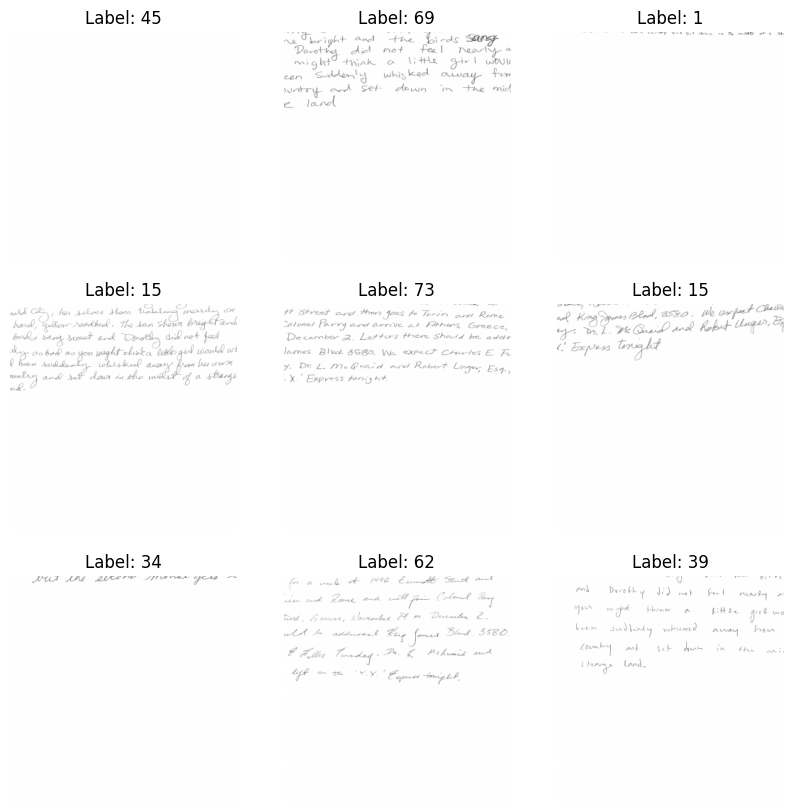

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_ds))

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(f"Label: {labels[i].numpy()}")
    plt.axis("off")
plt.show()

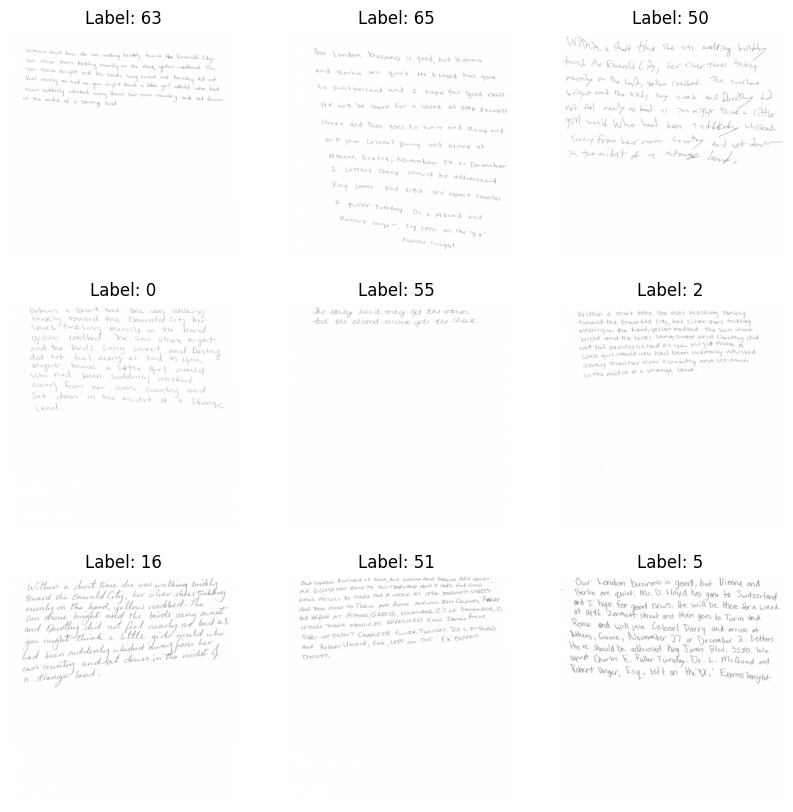

In [119]:
images, labels = next(iter(val_ds))

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(f"Label: {labels[i].numpy()}")
    plt.axis("off")
plt.show()

### Visualizing Augmentations

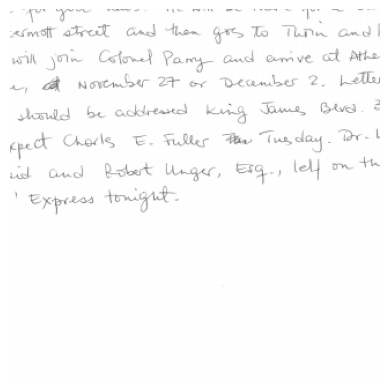

In [ ]:
images, labels = next(iter(train_ds))
plt.imshow(images[1].numpy())
plt.axis("off")
plt.show()

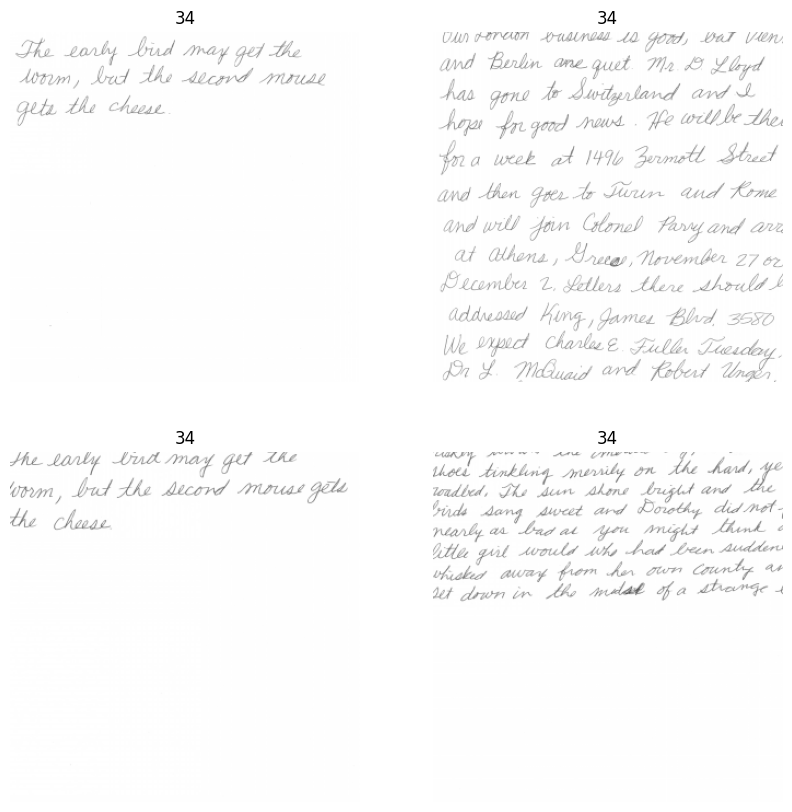

In [ ]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(10, 10))
for i in range(4):  # show first 9 images
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(int(labels[i]))
    plt.axis("off")

plt.show()

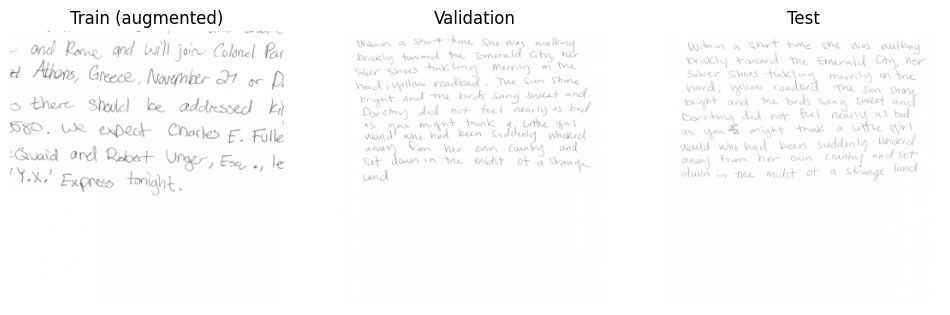

In [ ]:
train_imgs, _ = next(iter(train_ds))
val_imgs, _ = next(iter(val_ds))
test_imgs, _ = next(iter(test_ds))

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(train_imgs[0].numpy())
plt.title("Train (augmented)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(val_imgs[0].numpy())
plt.title("Validation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(test_imgs[0].numpy())
plt.title("Test")
plt.axis("off")

plt.show()


## Modelling

In [120]:
base_model=MobileNetV2(include_top = False,
                        classifier_activation="softmax",
                        weights = "imagenet",
                        input_shape=(IMAGE_SIZE + (3,))
                        )
model = alt_make_transfer_model(input_shape=INPUT_SHAPE, num_classes=90,
                                modname="MBNV2_augmented")

backbone = model.get_layer("mobilenetv2_1.00_224")
backbone.trainable = True
for layer in backbone.layers[:-5]:
    layer.trainable = False

/tmp/ipython-input-4223129732.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model=MobileNetV2(include_top = False,


In [121]:
model.summary()

Model: "MBNV2_augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_5 (TrueDivide)      │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_5 (Subtract)           │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 10, 10, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 90)             │       115,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,373,274 (9.05 MB)

 Trainable params: 835,290 (3.19 MB)

 Non-trainable params: 1,537,984 (5.87 MB)

#### epochs

In [122]:
%%time

epochs = 100

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc"),
             keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")],
    )

history = model.fit(
    train_ds,
    epochs= epochs,
    validation_data= val_ds)

model.save("/content/MobileNet_augmented.keras")

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - acc: 0.0146 - loss: 4.5650 - top3_acc: 0.0318 - val_acc: 0.0111 - val_loss: 5.3196 - val_top3_acc: 0.0333
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 723ms/step - acc: 0.0153 - loss: 4.5459 - top3_acc: 0.0293 - val_acc: 0.0111 - val_loss: 5.2844 - val_top3_acc: 0.0333
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 712ms/step - acc: 0.0088 - loss: 4.5340 - top3_acc: 0.0353 - val_acc: 0.0111 - val_loss: 5.2483 - val_top3_acc: 0.0333
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 720ms/step - acc: 0.0097 - loss: 4.5257 - top3_acc: 0.0348 - val_acc: 0.0111 - val_loss: 5.2032 - val_top3_acc: 0.0333
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 718ms/step - acc: 0.0110 - loss: 4.5288 - top3_acc: 0.0383 - val_acc: 0.0111 - val_loss: 5.1617 - val_top3_acc: 0.0333
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 709ms/step - acc: 0.0132 - loss: 4.5274 - top3_acc: 0.0324 - val_acc: 0.0185 - val_loss: 5.1120 - val_top3_acc: 0.0333
Epoch 7/100
22/22 ━━━━━━━━━━━━━

    Not learning??

In [123]:
lossacc = pd.DataFrame(history.history)
lossacc.to_csv("augmented_lossacc.csv")

#### Visualization/Evalution

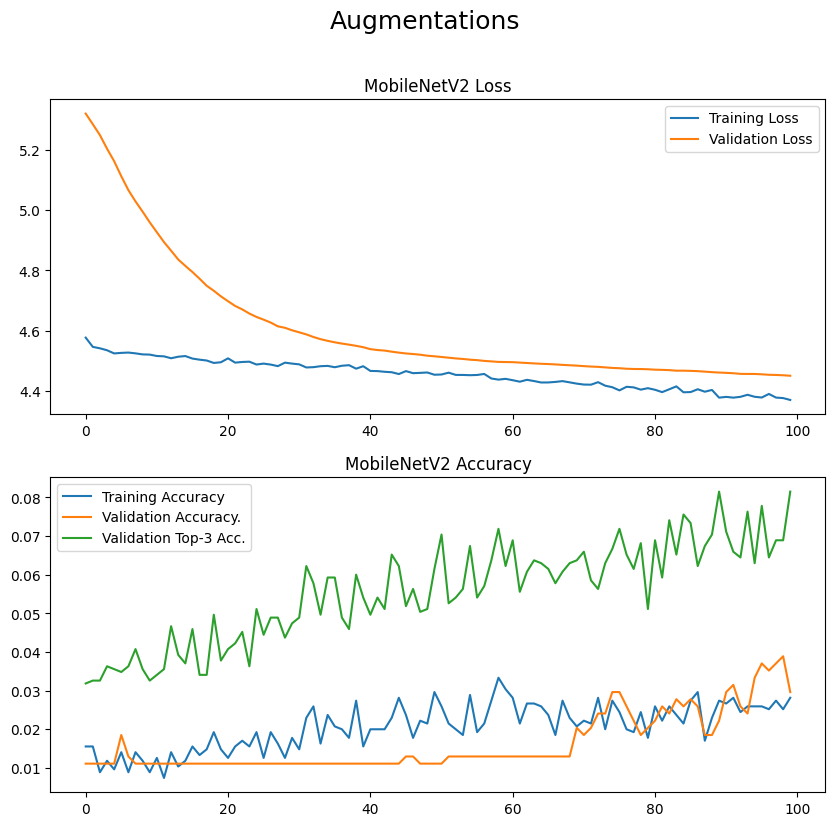

In [124]:
#plot loss and accuracy curves
plt.figure(figsize=(10,9))
plt.suptitle("Augmentations",size=18)
plt.subplot(2,1,1)
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history.history["acc"])),history.history["acc"],label="Training Accuracy")
plt.plot(range(len(history.history["val_acc"])),history.history["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(history.history["top3_acc"])),history.history["top3_acc"],label="Validation Top-3 Acc.")
plt.title("MobileNetV2 Accuracy")
plt.legend()

plt.show()

In [125]:
#test_loss, test_acc = model.evaluate(test_ds)
results = model.evaluate(test_ds, return_dict=True)

print(results)

#print(f"Test accuracy: {test_acc:.3f}")
#print(f"Test loss: {test_loss:.3f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 453ms/step - acc: 0.0458 - loss: 4.4396 - top3_acc: 0.0887
{'acc': 0.035185184329748154, 'loss': 4.449258327484131, 'top3_acc': 0.08888889104127884}


In [126]:
#Get predictions
y_pred_logits = model.predict(test_ds)
y_pred = np.argmax(y_pred_logits, axis=1)

y_true = np.concatenate([
    y.numpy() for _, y in test_ds
])

9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 910ms/step


In [127]:
print(classification_report(
    y_true,
    y_pred,
    target_names=reloadata.w_ids,
    digits=4
))

              precision    recall  f1-score   support

       w0001     0.0000    0.0000    0.0000         6
       w0002     0.0000    0.0000    0.0000         6
       w0003     0.0000    0.0000    0.0000         6
       w0004     0.0000    0.0000    0.0000         6
       w0005     0.0000    0.0000    0.0000         6
       w0006     0.0000    0.0000    0.0000         6
       w0009     0.0000    0.0000    0.0000         6
       w0010     0.0000    0.0000    0.0000         6
       w0011     0.0000    0.0000    0.0000         6
       w0012     0.0000    0.0000    0.0000         6
       w0013     0.0000    0.0000    0.0000         6
       w0015     0.0000    0.0000    0.0000         6
       w0016     0.0241    1.0000    0.0471         6
       w0017     0.0000    0.0000    0.0000         6
       w0018     0.0000    0.0000    0.0000         6
       w0020     0.0000    0.0000    0.0000         6
       w0022     0.0000    0.0000    0.0000         6
       w0023     0.0000    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


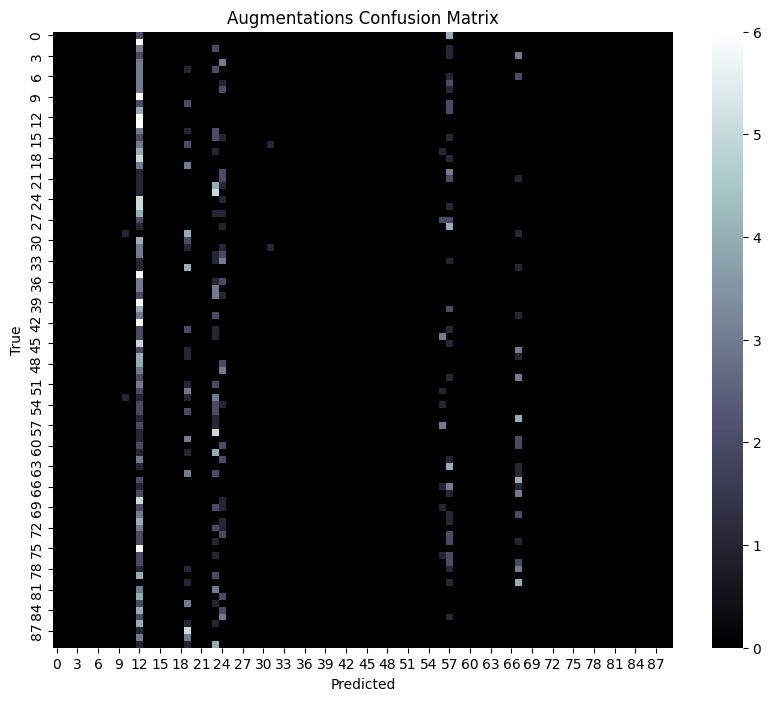

In [128]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.title("MobileNetV2")
sns.heatmap(cm, annot=False, cmap="bone")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Augmentations Confusion Matrix")
plt.show()